In [1]:
!nvidia-smi

Thu Apr  9 13:59:27 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.216.03             Driver Version: 535.216.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100 80GB PCIe          On  | 00000000:CA:00.0 Off |                   On |
| N/A   55C    P0             182W / 300W |                  N/A |     N/A      Default |
|                                         |                      |              Enabled |
+-----------------------------------------+----------------------+--

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
os.chdir('tracking_football/notebooks/yolov5/')
%pip install -r requirements.txt

ERROR: Ignored the following versions that require a different python version: 1.11.0 Requires-Python <3.13,>=3.9; 1.11.0rc1 Requires-Python <3.13,>=3.9; 1.11.0rc2 Requires-Python <3.13,>=3.9; 1.11.1 Requires-Python <3.13,>=3.9; 1.11.2 Requires-Python <3.13,>=3.9; 1.11.3 Requires-Python <3.13,>=3.9; 1.11.4 Requires-Python >=3.9; 1.12.0 Requires-Python >=3.9; 1.12.0rc1 Requires-Python >=3.9; 1.12.0rc2 Requires-Python >=3.9; 1.13.0 Requires-Python >=3.9; 1.13.0rc1 Requires-Python >=3.9; 1.13.1 Requires-Python >=3.9; 1.14.0 Requires-Python >=3.10; 1.14.0rc1 Requires-Python >=3.10; 1.14.0rc2 Requires-Python >=3.10; 1.14.1 Requires-Python >=3.10; 1.15.0 Requires-Python >=3.10; 1.15.0rc1 Requires-Python >=3.10; 1.15.0rc2 Requires-Python >=3.10; 1.15.1 Requires-Python >=3.10; 1.15.2 Requires-Python >=3.10; 1.15.3 Requires-Python >=3.10; 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.1

In [2]:
import torch

In [3]:
from typing import Generator
import matplotlib.pyplot as plt
import numpy as np
import cv2

def generate_frames(video_file: str) -> Generator[np.ndarray, None, None]:
    video = cv2.VideoCapture(video_file)
    
    while video.isOpened():
        success, frame = video.read()
        
        if not success:
            break
        
        yield frame
    
    video.release()
    
def plot_image(image: np.ndarray, size: int = 12) -> None:
    plt.figure(figsize=(size, size))
    plt.imshow(image[...,::-1])
    plt.show()

In [4]:
video_path = "tracking_football/sample_videos/0a2d9b_6.mp4"
frame_iterator = iter(generate_frames(video_file=video_path))

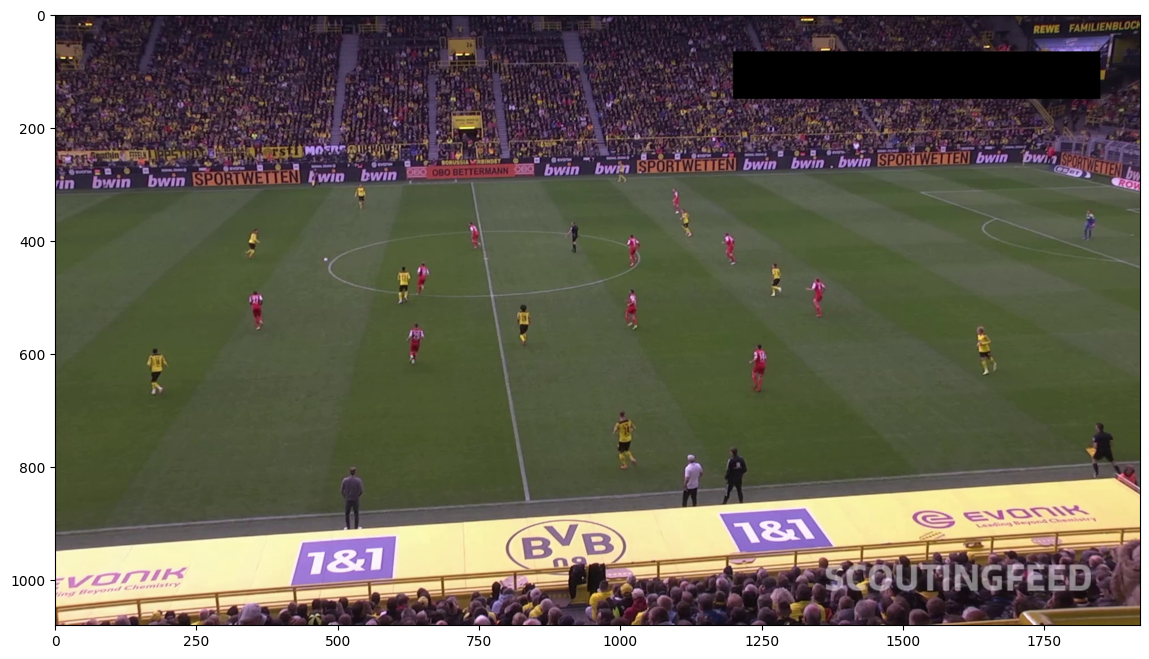

In [15]:
frame = next(frame_iterator)
plot_image(frame, 14)

In [17]:
import os
os.chdir('tracking_football/notebooks/yolov5')

In [18]:
!python detect.py --weights yolo5x.pt --img 1280 --conf 0.25 --source tracking_football/sample_videos/0a2d9b_6.mp4 --name coco_result

detect: weights=['yolo5x.pt'], source=tracking_football/sample_videos/0a2d9b_6.mp4, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=coco_result, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
requirements: Ultralytics requirements ['gitpython==3.1.43', 'matplotlib==3.7.1', 'numpy==1.24', 'opencv-python==4.8.0.76', 'pillow==10.3.0', 'psutil==5.9.5', 'PyYAML==6.0.1', 'requests==2.31.0', 'scipy==1.11.4', 'tqdm==4.66.4', 'ultralytics==8.2.20', 'seaborn==0.12.1', 'setuptools==67.7.2', 'wheel==0.43.0'] not found, attempting AutoUpdate...
ERROR: Ignored the following versions that require a different python version: 1.11.0 Requires-Python <3.13,>=3.9; 1.11.0rc1 Requires-Python <3.13,>=

In [ ]:
weights_path = ""
model = torch.hub.load('ultralytics/yolov5', 'custom', weights_path, device=0)

In [ ]:
results = model(frame, size=1280)
results.pandas()

In [ ]:
model.names

In [ ]:
!python detect.py --weights best.pt --img 1280 --conf 0.25 --source --name custom_result

In [ ]:
os.chdir('')

!cd ByteTrack && pip3 install -r requirements.txt
!cd ByteTrack && python3 setup.py develop
!pip install cython_bbox

In [ ]:
import sys
sys.path.append(f'')

In [ ]:
!pip install onemetric --quiet